# 2 - Self-supervised pretraining and niche discovery

Vignette 1 turned three MIBI-TOF images into 44 patch graphs. Here we:

1. pretrain a graph encoder with **BGRL**, which needs no labels,
2. attach a supervised head and export per-instance embeddings,
3. run the interpretability report to discover **spatial niches**.

---

### Read this before interpreting any number below

This dataset has **three images from two donors**. That is enough to
demonstrate the mechanics and enough for unsupervised niche discovery, but it
is *not* enough for supervised evaluation:

- Splitting by sample (the correct choice) puts one image in each of
  train/val/test.
- The only genuine bag-level variable is donor identity, and after that split
  the training image carries a single class.

So the fine-tuning step below trains on a **synthetic** target -- is a patch
epithelial-rich -- derived from the cell-type composition. That makes it a
positive control: it shows the training loop, the SSL-to-finetune transfer and
the attention head all working, and a pipeline that could not recover it would
be broken. It is not a biological finding, and the metrics are not a benchmark.

The niche analysis at the end stands on its own, because it is unsupervised.


## Setup


In [1]:
import json
import os
import re
import pathlib
import subprocess
import sys
import glob

import numpy as np
import pandas as pd

WORK = pathlib.Path("vignette_work").resolve()
RAW, PROCESSED = WORK / "data" / "raw", WORK / "data" / "processed"
assert PROCESSED.exists(), "Run vignette 1 first."
env = dict(os.environ, PROJECT_ROOT=str(WORK))

DATA_ARGS = [
    "data=spatial_omics",
    f"data.raw_manifest_path={RAW}/manifest.csv",
    f"data.processed_dir={PROCESSED}",
    "data.h5ad.coord_source=obsm",
    "data.h5ad.coord_key=spatial",
    "data.h5ad.categorical_label_columns=[cell_type]",
    "data.coord_scale_um=0.39",
    "data.sample_unit=tile",
    "data.tiling.tile_size_um=100",
    "data.tiling.stride_um=100",
    "data.min_cells=20",
    "data.tiling.min_cells=20",
    "data.split.train_val_test_split=[0.34,0.33,0.33]",
    "data.split.split_by=sample",
]


def run(args, tag):
    out = subprocess.run([sys.executable, "-m"] + args, capture_output=True, text=True, env=env)
    print(f"{tag}: exit {out.returncode}")
    if out.returncode:
        print(out.stdout[-2500:], out.stderr[-2500:])
        raise RuntimeError(f"{tag} failed - see output above")
    return out

## 1. BGRL pretraining (no labels)

BGRL learns node representations by matching two augmented views of the same
graph. Nothing here uses `donor_label`.

The augmentation preset matters. `bgrl_paper` adds Gaussian noise to a named
continuous feature (cell size) and requires the reserved 'unassigned'
cell-type slot. This cohort keeps `cell_size` in `obs`, not in the marker
matrix, so we use `uniform`, which drops edges and features independently of
structure and has no feature-name dependency.


In [2]:
run(
    [
        "grass_mil.train",
        "task=pretrain_bgrl",
        "model=bgrl_module",
        "trainer=cpu",
        "+augmentation@task.augmentation=uniform",
        *DATA_ARGS,
        f"paths.log_dir={WORK}/logs",
        "trainer.max_epochs=10",
    ],
    "BGRL pretraining",
)

bgrl_ckpt = sorted(
    glob.glob(f"{WORK}/logs/train/runs/*/checkpoints/*.ckpt"), key=os.path.getmtime
)[-1]
print("pretrained encoder:", os.path.relpath(bgrl_ckpt, WORK))

BGRL pretraining: exit 0
pretrained encoder: logs/train/runs/2026-08-17_09-36-53/checkpoints/last.ckpt


## 2. Fine-tune the MIL model

Pretraining gave an encoder. Fine-tuning attaches the MIL head and trains it
on a bag-level label: each patch is a bag, the ego-graphs inside it are the
instances, and per-class attention decides which of them the prediction
leans on.

This cohort has no usable clinical label -- see the note at the top -- so we
assign a **dummy target**: is this patch epithelial-rich? It is derived from
the cell-type composition the model can see, which makes it a *positive
control*: a working pipeline must recover it. It demonstrates the training
loop; it is not a finding.

Deriving it per patch rather than per image matters. Both classes then occur
in every image, so the split can stay at the sample level -- the correct
choice, since patches from one image share a donor and a batch.


In [3]:
import torch

index = json.loads((PROCESSED / "processed_index.json").read_text())
entries = index["entries"] if "entries" in index else index
meta = json.loads((PROCESSED / "metadata.json").read_text())
epithelial_code = meta["label_maps"]["cell_type"]["Epithelial"]

rows = []
for e in entries:
    g = torch.load(e["path"], weights_only=False)
    fraction = float((g.categorical_codes[:, 0] == epithelial_code).float().mean())
    rows.append({"patch_id": e["patch_id"], "fraction": fraction, "sample_id": e["sample_id"]})

patches = pd.DataFrame(rows)
# Split at the median so the classes are balanced.
patches["epithelial_rich"] = (patches["fraction"] > patches["fraction"].median()).astype(int)
patches[["patch_id", "epithelial_rich"]].to_csv(RAW / "patch_labels.csv", index=False)

print(
    patches.groupby("sample_id")["epithelial_rich"].agg(patches="size", positive="sum").to_string()
)

           patches  positive
sample_id                   
point16         16         6
point23         12         5
point8          16        11


/tmp/ci312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Both classes appear in every image, so no split is degenerate.


In [4]:
LABEL_ARGS = [
    f"data.graph_labels.label_file={RAW}/patch_labels.csv",
    "data.graph_labels.id_column=patch_id",
    "data.graph_labels.tasks=[epithelial_rich]",
    "data.graph_labels.scope=patch",
]
SAMPLER_ARGS = [
    "data.sampler.name=shadow_custom",
    "data.sampler.runtime.enabled=true",
    "data.sampler.runtime.depth=2",
    "data.sampler.runtime.num_neighbors=8",
]

out = run(
    [
        "grass_mil.train",
        # finetune_mil is the published head: per-class attention over the
        # instances of each bag. finetune_mean is the simpler alternative.
        "task=finetune_mil",
        "model=supervised_module",
        "trainer=cpu",
        f"model.init_from_ckpt={bgrl_ckpt}",
        "model.encoder_init_map=auto_bgrl_or_identity",
        *DATA_ARGS,
        *SAMPLER_ARGS,
        *LABEL_ARGS,
        # Labels are attached during precompute, so the graphs are rebuilt.
        "data.force_precompute=true",
        f"paths.log_dir={WORK}/logs",
        "trainer.max_epochs=8",
    ],
    "fine-tuning",
)

ft_ckpt = sorted(glob.glob(f"{WORK}/logs/train/runs/*/checkpoints/*.ckpt"), key=os.path.getmtime)[
    -1
]
print("fine-tuned checkpoint:", os.path.relpath(ft_ckpt, WORK))

# Surface the held-out metrics Lightning printed, so the run is visible
# rather than just its exit code. Rich draws a boxed table with ANSI colour and
# redraws the progress bar, so strip the codes and keep the final values only.
ansi = re.compile(r"\x1b\[[0-9;]*[A-Za-z]")
seen = {}
for line in out.stdout.splitlines():
    clean = ansi.sub("", line)
    for key in ("test/acc", "test/loss"):
        if key in clean:
            numbers = re.findall(r"\d+\.\d+", clean)
            if numbers:
                seen[key] = numbers[-1]
for key, value in seen.items():
    print(f"{key}: {value}")

fine-tuning: exit 0
fine-tuned checkpoint: logs/train/runs/2026-08-17_09-37-15/checkpoints/last.ckpt
test/acc: 0.6864105463027954
test/loss: 0.5490885376930237


The `test/` metrics printed above are on the held-out image. With three
images and a synthetic target they are a smoke test of the loop, not a
benchmark -- but the loss falling and the encoder transferring from
pretraining is what a real fine-tuning run looks like.

Swap `patch_labels.csv` for genuine clinical labels and the same command is
the real workflow.


## 3. Export per-instance embeddings

`grass-mil-predict` runs inference on the held-out split and writes the tables
the interpretability suite consumes. Enabling the ShaDow sampler means each
*instance* is an ego-graph around one cell, so the exported table describes
local neighbourhoods rather than whole patches.


In [5]:
run(
    [
        "grass_mil.inference.predict",
        f"ckpt_path={ft_ckpt}",
        # Must match the checkpoint's architecture.
        "task=finetune_mil",
        "model=supervised_module",
        "trainer=cpu",
        *DATA_ARGS,
        *SAMPLER_ARGS,
        *LABEL_ARGS,
        "interpretability.enabled=true",
        "interpretability.spatial.enabled=true",
        "interpretability.cells.enabled=true",
        "embeddings.enabled=true",
        f"paths.log_dir={WORK}/logs",
    ],
    "predict",
)

instance_table = sorted(
    glob.glob(f"{WORK}/logs/predict/runs/*/predictions/instance_table.csv"), key=os.path.getmtime
)[-1]
inst = pd.read_csv(instance_table)
print(os.path.relpath(instance_table, WORK))
print("instances:", len(inst))
print("embedding dims:", sum(c.startswith("inst_emb_") for c in inst.columns))
print("composition   :", [c for c in inst.columns if c.startswith("comp_")])
print("attention cols:", [c for c in inst.columns if c.startswith("attention")])
spatial_table = sorted(
    glob.glob(f"{WORK}/logs/predict/runs/*/predictions/spatial_table.csv"),
    key=os.path.getmtime,
)[-1]
print("spatial edges:", len(pd.read_csv(spatial_table)))
cell_table = sorted(
    glob.glob(f"{WORK}/logs/predict/runs/*/predictions/cell_table.csv"),
    key=os.path.getmtime,
)[-1]
cell_edge_table = sorted(
    glob.glob(f"{WORK}/logs/predict/runs/*/predictions/cell_edges.csv"),
    key=os.path.getmtime,
)[-1]
print(
    "cells:", len(pd.read_csv(cell_table)), "| cell-cell edges:", len(pd.read_csv(cell_edge_table))
)

predict: exit 0
logs/predict/runs/2026-08-17_09-37-28/predictions/instance_table.csv
instances: 1023
embedding dims: 128
composition   : ['comp_Imm_other', 'comp_Tcell_CD4', 'comp_Endothelial', 'comp_Tcell_CD8', 'comp_Fibroblast', 'comp_Myeloid_CD11c', 'comp_Myeloid_CD68', 'comp_Epithelial']
attention cols: ['attention', 'attention_c0', 'attention_logit_c0', 'attention_c1', 'attention_logit_c1']
spatial edges: 4554
cells: 17527 | cell-cell edges: 76310


> **Spatial edges.** The run above exports only the instance table. Adding
> `interpretability.spatial.enabled=true` also writes a `spatial_table` of
> edges between neighbouring instances, which the Moran's I, Ripley and
> neighbourhood-enrichment plugins need. Enable it if you want those analyses;
> the niche discovery below does not require it.


## 4. Discover niches

The report reduces the embedding space, clusters it into niches, orders them
by composition, and renders an HTML document. Niches are named in dendrogram
order; unassigned instances are labelled `Background`.


In [6]:
run(
    [
        "grass_mil.interpretability.report_cli",
        f"data.instance_table={instance_table}",
        f"data.spatial_table={spatial_table}",
        f"data.cell_table={cell_table}",
        f"data.cell_edge_table={cell_edge_table}",
        "interpretability/plugins@plugins=full",
        # min_cluster_size defaults to 0.5% of the instances, a good rule at
        # cohort scale. Here 0.5% of ~1000 is 5, which shatters the embedding
        # into ~90 niches of a handful of cells each, so pin it for the demo.
        "clustering.params.min_cluster_size=60",
        f"paths.log_dir={WORK}/logs",
        # report.yaml gets its own hydra run dir; pin it so outputs land
        # in the work directory instead of ./outputs/<date>/<time>/
        f"hydra.run.dir={WORK}/report",
        "report.pdf.enabled=false",
    ],
    "interpretability report",
)

report = sorted(glob.glob(f"{WORK}/report/**/report.html", recursive=True), key=os.path.getmtime)[
    -1
]
labels = sorted(
    glob.glob(f"{WORK}/report/**/artifacts/niche_labels.csv", recursive=True), key=os.path.getmtime
)[-1]
print("report:", os.path.relpath(report, WORK))
niches = pd.read_csv(labels)
print(niches["niche_label"].value_counts().sort_index().to_string())

interpretability report: exit 0
report: report/interpretability_report/report.html
niche_label
-1    111
 1     81
 2    377
 3    454


Open `report.html` in a browser for the full document. The rest of this
vignette pulls the same numbers out directly.


## 5. What distinguishes each niche?

Niches are clusters in embedding space; their meaning comes from the cell-type
composition of the neighbourhoods assigned to them.


In [7]:
merged = inst.merge(niches, on="instance_id")
comp_cols = [c for c in merged.columns if c.startswith("comp_")]

profile = merged.groupby("niche_label")[comp_cols].mean()
profile.columns = [c.replace("comp_", "") for c in profile.columns]
profile.round(3)

,Imm_other,Tcell_CD4,Endothelial,Tcell_CD8,Fibroblast,Myeloid_CD11c,Myeloid_CD68,Epithelial
niche_label,,,,,,,,
-1,0.160,0.076,0.021,0.068,0.059,0.015,0.025,0.576
1,0.233,0.060,0.000,0.003,0.084,0.022,0.044,0.555
2,0.196,0.250,0.034,0.169,0.291,0.033,0.022,0.005
3,0.058,0.254,0.056,0.330,0.048,0.068,0.043,0.142


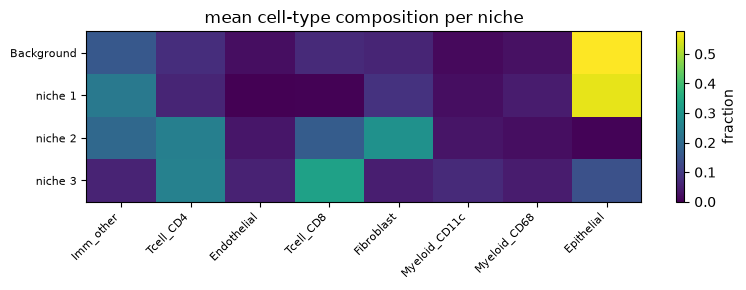

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(profile.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(profile.shape[1]))
ax.set_xticklabels(profile.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(profile.shape[0]))
ax.set_yticklabels([f"niche {i}" if i != -1 else "Background" for i in profile.index], fontsize=8)
ax.set_title("mean cell-type composition per niche")
fig.colorbar(im, ax=ax, label="fraction")
plt.tight_layout()

## 6. Where are the niches in the tissue?

The instance table carries each ego-graph's centroid, so niches can be mapped
straight back onto the image.


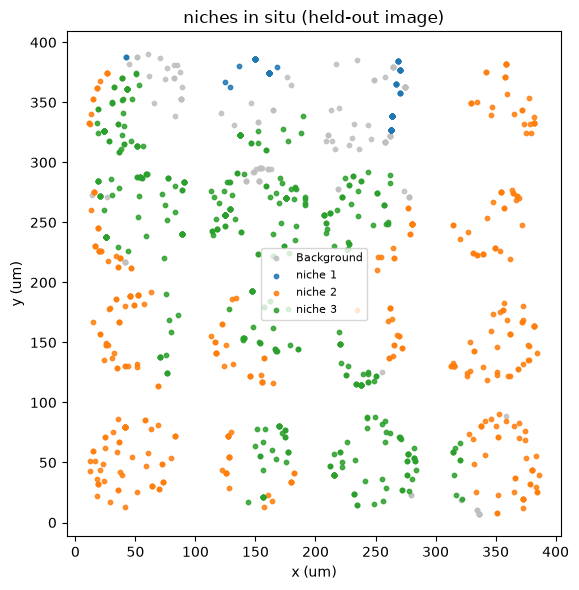

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
for lab, grp in merged.groupby("niche_label"):
    name = "Background" if lab == -1 else f"niche {lab}"
    ax.scatter(
        grp["center_x"],
        grp["center_y"],
        s=10,
        label=name,
        alpha=0.85,
        color="0.75" if lab == -1 else None,
    )
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.set_title("niches in situ (held-out image)")
ax.set_aspect("equal")
ax.legend(fontsize=8)
plt.tight_layout()

## 7. What is inside a niche?

The niches above are clusters of *neighbourhoods*. The tier-2 analyses go a
level down and describe the **cells** inside them: every node of every
sampled ego-graph is a row, carrying its own cell type, and each cell
inherits the niche of the ego-graph it came from.

That distinction matters. Two niches can have identical cell-type
*composition* and still differ completely in how those cells are arranged --
interleaved versus segregated. Only a cell-level statistic sees that.


In [10]:
from grass_mil.interpretability.tier2.cell_level import (
    attach_niche_labels_to_cells,
    per_niche_cell_type_enrichment,
    per_niche_cell_type_moran,
)

cells = pd.read_csv(cell_table)
cell_edges = pd.read_csv(cell_edge_table)

# Niche labels are assigned to instances; each cell inherits its ego-graph's.
labelled = inst[["instance_id"]].merge(niches, on="instance_id", how="left")
cells = attach_niche_labels_to_cells(
    cells, labelled["niche_label"].tolist(), labelled["instance_id"].tolist()
)
print("cells:", len(cells), "| all labelled:", bool(cells["niche_label"].notna().all()))

cells: 17527 | all labelled: True


### Cell-type contact enrichment, within each niche

For every niche, how often each pair of cell types is in contact, against a
null. Only edges with both endpoints inside the niche are used, so this
describes the niche's internal wiring.


niche 3: 8108 cells, 35502 edges


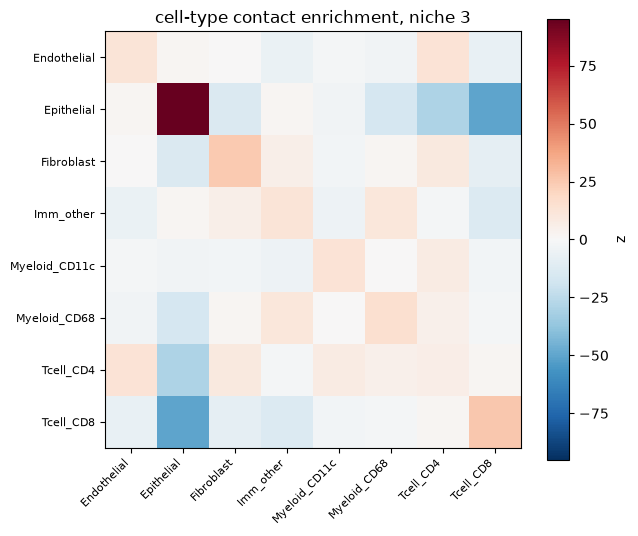

In [11]:
enr = per_niche_cell_type_enrichment(cells, cell_edges, n_perms=50, min_cells=30)

biggest = max(enr.n_cells, key=enr.n_cells.get)
z = enr.enrichment[biggest]
print(f"niche {biggest}: {enr.n_cells[biggest]} cells, {enr.n_edges[biggest]} edges")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
lim = np.nanmax(np.abs(z.values))
im = ax.imshow(z.values, cmap="RdBu_r", vmin=-lim, vmax=lim)
ax.set_xticks(range(len(z.columns)))
ax.set_xticklabels(z.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(z.index)))
ax.set_yticklabels(z.index, fontsize=8)
ax.set_title(f"cell-type contact enrichment, niche {biggest}")
fig.colorbar(im, ax=ax, label="z")
plt.tight_layout()

Read it as: warm on the diagonal means that cell type sits next to itself
(tumour nests, lymphoid aggregates); cool off-diagonal means two types
actively avoid contact.


### Are cell types spatially clustered inside a niche?

Moran's I of each cell-type indicator over the niche's cell graph. High
values mean that type forms contiguous patches rather than being scattered.


In [12]:
mo = per_niche_cell_type_moran(cells, cell_edges, n_perms=50)
stat = mo.statistic.copy()
stat.columns = [c.replace("ct_", "") for c in stat.columns]
stat.round(2).head(8)

,Endothelial,Epithelial,Fibroblast,Imm_other,Myeloid_CD11c,Myeloid_CD68,Tcell_CD4,Tcell_CD8
-1,0.12,0.54,0.18,0.30,0.16,0.02,0.12,0.30
1,NaN,0.20,0.13,0.13,-0.04,-0.05,-0.07,0.23
2,0.16,0.35,0.17,0.14,0.07,0.02,0.04,0.18
3,0.08,0.64,0.17,0.09,0.09,0.11,0.05,0.25


The report generated above contains all of this, plus Ripley cross-L between
cell types, filtration curves over cell-cell distances, and the global
`niche_label_moran` asking whether niches form contiguous territories.


## Where to go next

- **A real cohort.** With enough samples for a genuine sample-level split,
  swap `task=finetune_mean` for `task=finetune_mil` to get per-class attention
  and the margin attribution described in `docs/method_fidelity.md`.
- **Tuning the niches.** `clustering` and `reduction` are config groups. Note
  that `report.yaml` is `@package _global_`, so switching a preset needs the
  package form: `interpretability/clustering@clustering=kmeans`.
- **More analyses.** `interpretability/plugins@plugins=full` enables
  neighbourhood enrichment, filtration curves and the spatial statistics.

See `docs/workflows_train_infer.md` for the full set of workflows and
`docs/hyperparameter_reference.md` for every configuration key.
